# 02: Metric Construction and Validation for Discovery Quality

The previous notebook created a user-day panel from KuaiRec and established a causal question: recommendation exposure can drive immediate activity, but product teams usually care about whether that exposure creates meaningful discovery, satisfaction, and durable return behavior. This notebook turns that setup into explicit measurement objects.

The measurement problem is subtle. A click-like metric is easy to increase, but it can reward low-value behavior such as curiosity clicks, accidental plays, or short sessions with low satisfaction value. A discovery-quality metric should do more than count immediate response. It should combine three ideas.

- **Discovery exposure**: did the user receive less-obvious or broader content, such as long-tail videos or categories outside their recent consumption history?
- **Satisfaction depth**: did the interaction look meaningful, using watch ratio, valid play, completion, and abandonment proxies?
- **Future value validation**: do higher metric values line up with future activity, while remaining distinct from past activity volume?

A key causal discipline in this notebook is separation of roles. Exposure-like variables are candidates for treatments or policy levers. Satisfaction-like variables are plausible mediators. Future outcomes are used only for validation; they are never used to build the metric itself. That separation keeps later mediation analysis understandable.

<!-- dataset-experiment-context -->
## Dataset and Mediation Design Context

This project uses KuaiRec interaction logs and metadata organized into active user-day records. The workflow constructs discovery-breadth, satisfaction-depth, quality-adjusted discovery, and shallow-click-pressure metrics from logged viewing behavior.

The data come from a real observational recommendation log. Discovery exposure, satisfaction depth, and future engagement arise from platform behavior, so the mediation analysis needs explicit identifying assumptions. The treatment is high discovery-breadth exposure, the mediator is same-day satisfaction depth, and the primary outcome is future seven-day interactions.

The project asks whether discovery exposure relates to future value directly, indirectly through satisfaction depth, or both. Because mediation in observational logs requires strong assumptions, the notebooks emphasize metric construction, temporal ordering, overlap, placebo-style checks, robustness across definitions, and model sensitivity.

**Role of this notebook.** This notebook constructs and validates discovery, satisfaction, composite quality, and guardrail metrics before using them in causal mediation.

<!-- mathematical-setup -->

## Mathematical Setup

Metric construction turns raw behavior into analyzable variables. A normalized component can be written as

$$
Z_{ij}=\frac{X_{ij}-\bar X_j}{s_j},
$$

where \(X_{ij}\) is component \(j\) for row \(i\). A composite discovery-quality metric is then a weighted combination,

$$
M_i=\sum_{j=1}^p \omega_j Z_{ij}.
$$

Validation checks whether the metric is stable, interpretable, and predictive of later behavior. The goal is to create a mediator candidate that matches the causal story and respects the timing of the design.


#### 1. Load Libraries and Paths

This cell imports the data, plotting, and utility libraries used throughout the notebook. It also defines the raw input paths from the setup notebook and the output paths for the metric panel, validation tables, and figures created here.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display

warnings.filterwarnings("ignore", category=FutureWarning)

# Keep the visual style consistent with the earlier notebooks while staying readable in VS Code/Jupyter.
sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (11, 6)
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.labelsize"] = 11
pd.set_option("display.max_columns", 120)
pd.set_option("display.max_colwidth", 120)

# Detect the repository root whether the notebook is run from the repo root or from this notebook folder.
PROJECT_ROOT = Path.cwd().resolve()
while not (PROJECT_ROOT / "data").exists() and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
NOTEBOOK_DIR = PROJECT_ROOT / "notebooks" / "discovery_quality_mediation"


PANEL_INPUT = PROCESSED_DIR / "kuairec_discovery_quality_mediation_panel.parquet"
INTERACTIONS_INPUT = PROCESSED_DIR / "kuairec_discovery_quality_interactions_sample.parquet"
ITEM_FEATURES_INPUT = PROCESSED_DIR / "kuairec_discovery_quality_item_features.parquet"
READINESS_INPUT = PROCESSED_DIR / "kuairec_discovery_quality_readiness.csv"

METRIC_PANEL_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_metric_panel.parquet"
METRIC_REGISTRY_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_metric_registry.csv"
METRIC_VALIDATION_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_metric_validation.csv"
METRIC_CORRELATION_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_metric_correlations.csv"
METRIC_DECILE_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_metric_deciles.csv"
METRIC_SELECTION_OUTPUT = PROCESSED_DIR / "kuairec_discovery_quality_selected_metrics.csv"


The directories follow the same pattern used by the rest of the repository. Durable data artifacts go to `data/processed` so later notebooks can load a stable metric panel.

#### 2. Load the Setup Artifacts

This cell loads the active user-day mediation panel and the supporting interaction/item artifacts from the setup notebook. The panel is the main unit of analysis: one row is one active user on one calendar day, with same-day exposure and satisfaction signals plus future engagement outcomes.

In [2]:
metric_base = pd.read_parquet(PANEL_INPUT)
interactions = pd.read_parquet(INTERACTIONS_INPUT)
item_features = pd.read_parquet(ITEM_FEATURES_INPUT)
readiness = pd.read_csv(READINESS_INPUT)

load_summary = pd.DataFrame(
    {
        "artifact": ["mediation_panel", "interaction_sample", "item_features", "readiness_checks"],
        "rows": [len(metric_base), len(interactions), len(item_features), len(readiness)],
        "columns": [metric_base.shape[1], interactions.shape[1], item_features.shape[1], readiness.shape[1]],
    }
)

display(load_summary)
display(readiness)


,artifact,rows,columns
0,mediation_panel,8199,81
1,interaction_sample,440788,37
2,item_features,3327,27
3,readiness_checks,6,3


,check,value,notes
0,active_user_days,8199.000000,Rows available for active-day mediation setup.
1,sampled_users,133.000000,Users represented in the mediation panel.
2,treatment_rate,0.501525,Should be neither near 0 nor near 1.
3,mediator_satisfaction_std,0.176618,Mediator must vary across user-days.
4,future_7day_interactions_std,180.363332,Outcome must vary across user-days.
5,max_key_variable_missing_rate,0.000000,Key variables should be complete or nearly complete.


The readiness table is the first sanity check for this notebook. The treatment rate is close to balanced, the mediator and future outcomes vary, and key missingness is zero. That means metric validation can focus on substantive behavior.

## Metric Construction and Validation Workflow

### State the Measurement Contract

Before building formulas, this cell creates a small data dictionary for the key columns used here. This prevents the notebook from becoming a bag of engineered features. Each metric has to map back to a causal role: exposure, mediator, outcome, or history control.

In [3]:
# State the measurement contract.
measurement_contract = pd.DataFrame(
    [
        {
            "role": "exposure",
            "column": "discovery_candidate_share",
            "meaning": "Share of same-day interactions that are platform long-tail or first category exposures for the user.",
            "used_for_metric_building": True,
            "uses_future_information": False,
        },
        {
            "role": "exposure",
            "column": "long_tail_share",
            "meaning": "Share of same-day interactions with lower platform-level exposure items.",
            "used_for_metric_building": True,
            "uses_future_information": False,
        },
        {
            "role": "exposure",
            "column": "new_category_share",
            "meaning": "Share of same-day interactions from categories not previously seen for that user in the sampled history.",
            "used_for_metric_building": True,
            "uses_future_information": False,
        },
        {
            "role": "mediator",
            "column": "high_satisfaction_share",
            "meaning": "Share of interactions with watch ratio at least 0.8.",
            "used_for_metric_building": True,
            "uses_future_information": False,
        },
        {
            "role": "mediator",
            "column": "valid_play_share",
            "meaning": "Share of interactions with enough watch time to look like a real play.",
            "used_for_metric_building": True,
            "uses_future_information": False,
        },
        {
            "role": "mediator",
            "column": "short_abandon_share",
            "meaning": "Share of interactions with very low watch ratio, used as a quality guardrail.",
            "used_for_metric_building": True,
            "uses_future_information": False,
        },
        {
            "role": "outcome",
            "column": "outcome_future_7day_interactions",
            "meaning": "Seven-day future interaction count after the current day.",
            "used_for_metric_building": False,
            "uses_future_information": True,
        },
        {
            "role": "outcome",
            "column": "outcome_future_7day_active_days",
            "meaning": "Seven-day future active-day count after the current day.",
            "used_for_metric_building": False,
            "uses_future_information": True,
        },
        {
            "role": "history_control",
            "column": "prior_3day_interactions",
            "meaning": "Recent activity before the current day, used to detect whether a metric merely tracks user activity level.",
            "used_for_metric_building": False,
            "uses_future_information": False,
        },
    ]
)

display(measurement_contract)


,role,column,meaning,used_for_metric_building,uses_future_information
0,exposure,discovery_candidate_share,Share of same-day interactions that are platform long-tail or first category exposures for the user.,True,False
1,exposure,long_tail_share,Share of same-day interactions with lower platform-level exposure items.,True,False
2,exposure,new_category_share,Share of same-day interactions from categories not previously seen for that user in the sampled history.,True,False
3,mediator,high_satisfaction_share,Share of interactions with watch ratio at least 0.8.,True,False
4,mediator,valid_play_share,Share of interactions with enough watch time to look like a real play.,True,False
5,mediator,short_abandon_share,"Share of interactions with very low watch ratio, used as a quality guardrail.",True,False
6,outcome,outcome_future_7day_interactions,Seven-day future interaction count after the current day.,False,True
7,outcome,outcome_future_7day_active_days,Seven-day future active-day count after the current day.,False,True
8,history_control,prior_3day_interactions,"Recent activity before the current day, used to detect whether a metric merely tracks user activity level.",False,False


The contract makes one important rule explicit. Future outcomes serve as validation targets for metrics defined from current behavior. That is what makes the later evidence more credible. If a metric were built from future behavior, its validation would be circular.

#### 4. Create Normalization Helpers

Metrics are easier to compare when they live on similar scales. This cell defines small helpers for clipping rates, min-max scaling, Spearman correlation, and decile assignment. The helpers also handle constant columns gracefully so the notebook fails less often when the sample changes.

In [4]:
# Create normalization helpers.
def clip_rate(series):
    """
    Clip a rate-style metric to the unit interval.
    
    Idea
    ----
    The helper keeps constructed discovery and satisfaction metrics within interpretable probability-like bounds while preserving missing values.
    
    Parameters
    ----------
    series : object
        Input pandas Series.
    
    Returns
    -------
    pandas.Series
        Rate values clipped to the interval from zero to one.
    """
    return series.astype(float).clip(lower=0, upper=1)


def minmax_score(series):
    """
    Scale a metric to the unit interval for composite scoring.
    
    Idea
    ----
    The helper makes discovery and satisfaction components comparable before combining them into quality or guardrail scores.
    
    Parameters
    ----------
    series : object
        Input pandas Series.
    
    Returns
    -------
    pandas.Series
        Min-max scaled score, or a neutral score when the input has no variation.
    """
    values = series.astype(float)
    min_value = values.min(skipna=True)
    max_value = values.max(skipna=True)
    if pd.isna(min_value) or pd.isna(max_value) or np.isclose(max_value, min_value):
        return pd.Series(0.5, index=series.index)
    return (values - min_value) / (max_value - min_value)


def safe_spearman(frame, left, right):
    """
    Compute a guarded Spearman correlation for metric validation.
    
    Idea
    ----
    The helper avoids misleading correlations when either metric is missing or constant, which is common in sparse user-day panels.
    
    Parameters
    ----------
    frame : object
        Input analysis table for the current project step.
    left : object
        Name of the first metric column.
    right : object
        Name of the second metric column.
    
    Returns
    -------
    float
        Spearman correlation value or missing value when the comparison is not defined.
    """
    pair = frame[[left, right]].dropna()
    if len(pair) < 3 or pair[left].nunique() < 2 or pair[right].nunique() < 2:
        return np.nan
    return pair[left].corr(pair[right], method="spearman")


def add_decile(frame, metric):
    """
    Add stable decile labels for a constructed metric.
    
    Idea
    ----
    The helper supports decile validation plots while handling tied metric values that can break ordinary quantile cuts.
    
    Parameters
    ----------
    frame : object
        Input analysis table for the current project step.
    metric : object
        Metric column used for binning or validation.
    
    Returns
    -------
    pandas.Series
        Decile labels aligned with the input metric.
    """
    ranked = frame[metric].rank(method="first")
    return pd.qcut(ranked, q=10, labels=False, duplicates="drop") + 1

helper_summary = pd.DataFrame(
    {
        "helper": ["clip_rate", "minmax_score", "safe_spearman", "add_decile"],
        "purpose": [
            "Protect rate-like inputs from drifting outside [0, 1].",
            "Place count or score variables on a comparable [0, 1] scale.",
            "Compute rank correlation without breaking on degenerate columns.",
            "Create ordered metric groups for top-versus-bottom validation.",
        ],
    }
)

display(helper_summary)


,helper,purpose
0,clip_rate,"Protect rate-like inputs from drifting outside [0, 1]."
1,minmax_score,"Place count or score variables on a comparable [0, 1] scale."
2,safe_spearman,Compute rank correlation without breaking on degenerate columns.
3,add_decile,Create ordered metric groups for top-versus-bottom validation.


These helpers are deliberately simple. The goal is to keep each metric definition readable and reproducible. Later notebooks can replace a hand-built score with learned weights; this notebook starts with transparent measurement.

### Build Metric Components

This cell prepares reusable components from the user-day panel. Some columns are already rates; others need transformation. For example, raw interaction counts are converted to a scaled log-volume score so high-volume days matter without letting extreme activity dominate every metric.

In [5]:
metric_panel = metric_base.copy()
metric_panel = metric_panel.sort_values(["user_id", "event_date"]).reset_index(drop=True)

# Category breadth is another discovery signal: a day with many categories per interaction is broader.
metric_panel["category_breadth_rate"] = (
    metric_panel["unique_categories"] / metric_panel["interactions"].replace(0, np.nan)
).fillna(0)
metric_panel["category_breadth_rate"] = clip_rate(metric_panel["category_breadth_rate"])

# Scaled volume keeps activity information available without treating raw clicks as the target metric.
metric_panel["engagement_volume_score"] = minmax_score(np.log1p(metric_panel["interactions"]))
metric_panel["recent_activity_score"] = minmax_score(np.log1p(metric_panel["prior_3day_interactions"]))

rate_inputs = [
    "discovery_candidate_share",
    "long_tail_share",
    "new_category_share",
    "valid_play_share",
    "high_satisfaction_share",
    "complete_or_rewatch_share",
    "short_abandon_share",
    "avg_satisfaction_score",
]
for col in rate_inputs:
    metric_panel[col] = clip_rate(metric_panel[col])

component_summary = metric_panel[
    [
        "category_breadth_rate",
        "engagement_volume_score",
        "recent_activity_score",
        "discovery_candidate_share",
        "long_tail_share",
        "new_category_share",
        "valid_play_share",
        "high_satisfaction_share",
        "complete_or_rewatch_share",
        "short_abandon_share",
        "avg_satisfaction_score",
    ]
].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).T

display(component_summary)


,count,mean,std,min,10%,25%,50%,75%,90%,max
category_breadth_rate,8199.0,0.426961,0.163345,0.105802,0.257732,0.313433,0.396226,0.500000,0.625000,1.0
engagement_volume_score,8199.0,0.608386,0.157664,0.000000,0.416686,0.535855,0.640961,0.715275,0.771506,1.0
recent_activity_score,8199.0,0.774028,0.143744,0.000000,0.629895,0.733243,0.808920,0.857085,0.892857,1.0
discovery_candidate_share,8199.0,0.364368,0.172628,0.000000,0.090909,0.271010,0.390244,0.480570,0.555556,1.0
long_tail_share,8199.0,0.351875,0.164697,0.000000,0.090909,0.260572,0.377551,0.466667,0.539474,1.0
new_category_share,8199.0,0.020453,0.085513,0.000000,0.000000,0.000000,0.000000,0.000000,0.029733,1.0
valid_play_share,8199.0,0.939417,0.095783,0.000000,0.830717,0.920000,0.975610,1.000000,1.000000,1.0
high_satisfaction_share,8199.0,0.468649,0.176618,0.000000,0.257489,0.349699,0.461538,0.575758,0.692308,1.0
complete_or_rewatch_share,8199.0,0.323119,0.171901,0.000000,0.128968,0.208333,0.302326,0.412944,0.533537,1.0
short_abandon_share,8199.0,0.101160,0.100637,0.000000,0.000000,0.037736,0.076923,0.133333,0.214286,1.0


The components cover three different measurement families: breadth of discovery, depth of satisfaction, and volume of immediate activity. Keeping these separate lets us later ask whether a composite metric is truly adding information or just renaming clicks.

### Construct Candidate Discovery-Quality Metrics

This cell creates the candidate metrics. The formulas are transparent on purpose.

- `discovery_breadth_score` is exposure-like and can support treatment definitions.
- `satisfaction_depth_score` is mediator-like and should be handled as post-exposure.
- `quality_adjusted_discovery_score` combines discovery and satisfaction, making it useful as a product metric. The mediation analysis uses separately defined treatment and mediator variables.
- `shallow_click_pressure_score` is a guardrail: high immediate volume paired with weak satisfaction.

In [6]:
# Construct candidate discovery-Quality metrics.
metric_panel["discovery_breadth_score"] = clip_rate(
    0.45 * metric_panel["discovery_candidate_share"]
    + 0.30 * metric_panel["long_tail_share"]
    + 0.15 * metric_panel["new_category_share"]
    + 0.10 * metric_panel["category_breadth_rate"]
)

metric_panel["satisfaction_depth_score"] = clip_rate(
    0.30 * metric_panel["high_satisfaction_share"]
    + 0.25 * metric_panel["valid_play_share"]
    + 0.20 * metric_panel["avg_satisfaction_score"]
    + 0.15 * metric_panel["complete_or_rewatch_share"]
    + 0.10 * (1 - metric_panel["short_abandon_share"])
)

metric_panel["quality_adjusted_discovery_score"] = np.sqrt(
    metric_panel["discovery_breadth_score"] * metric_panel["satisfaction_depth_score"]
)

metric_panel["balanced_discovery_quality_score"] = clip_rate(
    0.50 * metric_panel["discovery_breadth_score"]
    + 0.50 * metric_panel["satisfaction_depth_score"]
)

metric_panel["volume_weighted_quality_score"] = minmax_score(
    np.log1p(metric_panel["interactions"]) * metric_panel["quality_adjusted_discovery_score"]
)

metric_panel["shallow_click_pressure_score"] = clip_rate(
    metric_panel["engagement_volume_score"] * (1 - metric_panel["satisfaction_depth_score"])
)

# These binary flags are convenient for summaries. Only the discovery-breadth flag is exposure-like.
metric_panel["high_discovery_breadth_day"] = (
    metric_panel["discovery_breadth_score"] >= metric_panel["discovery_breadth_score"].median()
).astype("int8")
metric_panel["high_quality_adjusted_discovery_day"] = (
    metric_panel["quality_adjusted_discovery_score"] >= metric_panel["quality_adjusted_discovery_score"].median()
).astype("int8")

candidate_metrics = [
    "discovery_breadth_score",
    "satisfaction_depth_score",
    "quality_adjusted_discovery_score",
    "balanced_discovery_quality_score",
    "volume_weighted_quality_score",
    "shallow_click_pressure_score",
]

metric_registry = pd.DataFrame(
    [
        {
            "metric": "discovery_breadth_score",
            "role": "exposure_like",
            "formula_summary": "Weighted mix of discovery-candidate, long-tail, new-category, and category-breadth rates.",
            "causal_use": "Candidate exposure/treatment measure for later mediation.",
            "caution": "Still observational; high discovery days may reflect user preference and recommender selection.",
        },
        {
            "metric": "satisfaction_depth_score",
            "role": "mediator_like",
            "formula_summary": "Weighted mix of high watch ratio, valid plays, satisfaction score, completion, and low abandonment.",
            "causal_use": "Candidate mediator between discovery exposure and future value.",
            "caution": "Post-exposure signal; do not use as a pre-treatment control.",
        },
        {
            "metric": "quality_adjusted_discovery_score",
            "role": "composite_product_metric",
            "formula_summary": "Geometric mean of discovery breadth and satisfaction depth.",
            "causal_use": "Useful for monitoring and policy ranking; not a clean treatment in mediation.",
            "caution": "Combines exposure and mediator information.",
        },
        {
            "metric": "balanced_discovery_quality_score",
            "role": "composite_product_metric",
            "formula_summary": "Arithmetic average of discovery breadth and satisfaction depth.",
            "causal_use": "Transparent composite metric for comparison with the geometric version.",
            "caution": "Can look good when only one component is high.",
        },
        {
            "metric": "volume_weighted_quality_score",
            "role": "business_metric",
            "formula_summary": "Quality-adjusted discovery scaled by same-day log interaction volume.",
            "causal_use": "Useful for product prioritization where scale matters.",
            "caution": "More click-sensitive than the pure quality metrics.",
        },
        {
            "metric": "shallow_click_pressure_score",
            "role": "guardrail",
            "formula_summary": "High immediate volume combined with low satisfaction depth.",
            "causal_use": "Negative signal or guardrail for click-heavy recommendation behavior.",
            "caution": "A high value is bad; correlations should be read with the sign reversed.",
        },
    ]
)

metric_distribution = metric_panel[candidate_metrics].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9]).T

display(metric_registry)
display(metric_distribution)


,metric,role,formula_summary,causal_use,caution
0,discovery_breadth_score,exposure_like,"Weighted mix of discovery-candidate, long-tail, new-category, and category-breadth rates.",Candidate exposure/treatment measure for later mediation.,Still observational; high discovery days may reflect user preference and recommender selection.
1,satisfaction_depth_score,mediator_like,"Weighted mix of high watch ratio, valid plays, satisfaction score, completion, and low abandonment.",Candidate mediator between discovery exposure and future value.,Post-exposure signal; do not use as a pre-treatment control.
2,quality_adjusted_discovery_score,composite_product_metric,Geometric mean of discovery breadth and satisfaction depth.,Useful for monitoring and policy ranking; not a clean treatment in mediation.,Combines exposure and mediator information.
3,balanced_discovery_quality_score,composite_product_metric,Arithmetic average of discovery breadth and satisfaction depth.,Transparent composite metric for comparison with the geometric version.,Can look good when only one component is high.
4,volume_weighted_quality_score,business_metric,Quality-adjusted discovery scaled by same-day log interaction volume.,Useful for product prioritization where scale matters.,More click-sensitive than the pure quality metrics.
5,shallow_click_pressure_score,guardrail,High immediate volume combined with low satisfaction depth.,Negative signal or guardrail for click-heavy recommendation behavior.,A high value is bad; correlations should be read with the sign reversed.


,count,mean,std,min,10%,25%,50%,75%,90%,max
discovery_breadth_score,8199.0,0.315292,0.122804,0.022222,0.122665,0.247618,0.330000,0.395932,0.452737,0.925000
satisfaction_depth_score,8199.0,0.618626,0.112600,0.000000,0.482869,0.547525,0.617436,0.685637,0.753525,1.000000
quality_adjusted_discovery_score,8199.0,0.429600,0.106185,0.000000,0.275625,0.374607,0.443178,0.499683,0.548292,0.921954
balanced_discovery_quality_score,8199.0,0.466959,0.085621,0.050000,0.359290,0.413900,0.470779,0.523202,0.569368,0.925000
volume_weighted_quality_score,8199.0,0.487750,0.167229,0.000000,0.227026,0.400079,0.518041,0.605890,0.674227,1.000000
shallow_click_pressure_score,8199.0,0.233236,0.089682,0.000000,0.116157,0.178974,0.236637,0.291770,0.341866,0.614382


The registry is the most important table in the notebook. It says which metrics are appropriate for causal exposure analysis and which ones are better treated as mediators or monitoring metrics. That distinction prevents post-treatment leakage in later notebooks.

#### 7. Visualize Metric Distributions

A metric that is almost always the same value has limited usefulness for causal analysis or product monitoring. This cell plots each candidate metric distribution so we can see spread, skew, and whether any score collapses to a narrow band.

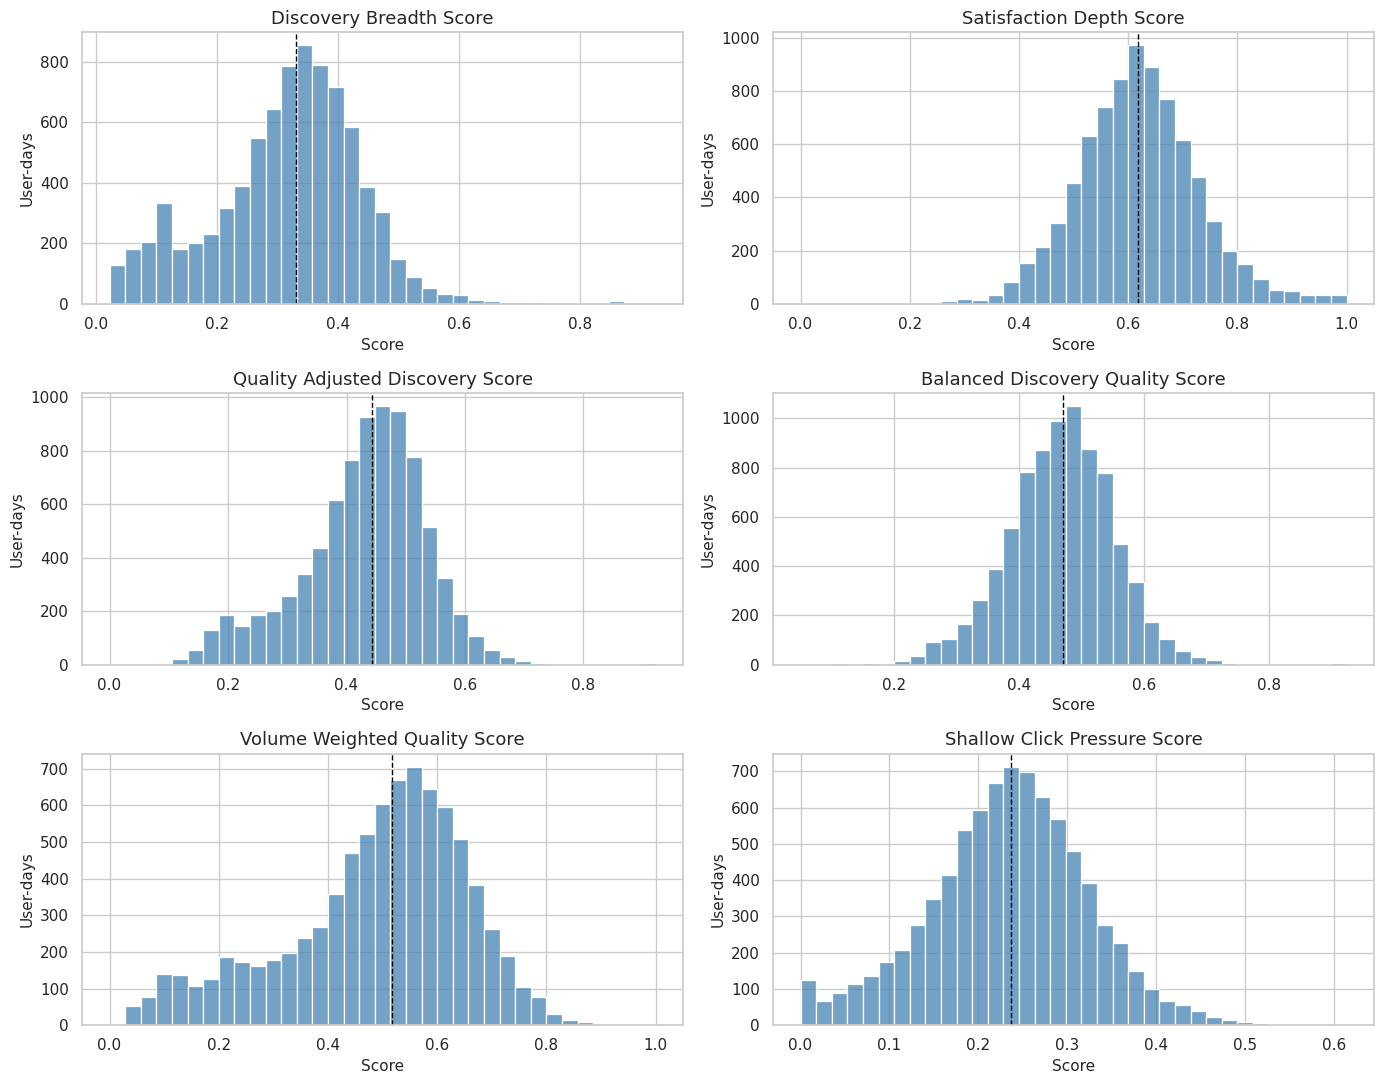

In [7]:
# Visualize metric distributions.
metric_long = metric_panel[candidate_metrics].melt(var_name="metric", value_name="value")

metric_name_order = [
    "discovery_breadth_score",
    "satisfaction_depth_score",
    "quality_adjusted_discovery_score",
    "balanced_discovery_quality_score",
    "volume_weighted_quality_score",
    "shallow_click_pressure_score",
]

fig, axes = plt.subplots(3, 2, figsize=(14, 11), sharex=False)
axes = axes.flatten()
for ax, metric in zip(axes, metric_name_order):
    sns.histplot(
        data=metric_long.query("metric == @metric"),
        x="value",
        bins=35,
        color="steelblue",
        edgecolor="white",
        ax=ax,
    )
    ax.axvline(metric_panel[metric].median(), color="black", linestyle="--", linewidth=1)
    ax.set_title(metric.replace("_", " ").title())
    ax.set_xlabel("Score")
    ax.set_ylabel("User-days")

plt.tight_layout()
plt.show()


The distributions show whether the metrics provide enough variation for grouping and modeling. The median reference line is also a practical reminder that later binary contrasts should be based on a score with real spread.

#### 8. Check Same-Day Metric Relationships

This cell calculates correlations among candidate metrics and the raw same-day components. The purpose is to understand what each metric is mostly measuring. A good composite should relate to discovery and satisfaction, while the guardrail should move in the opposite direction from satisfaction.

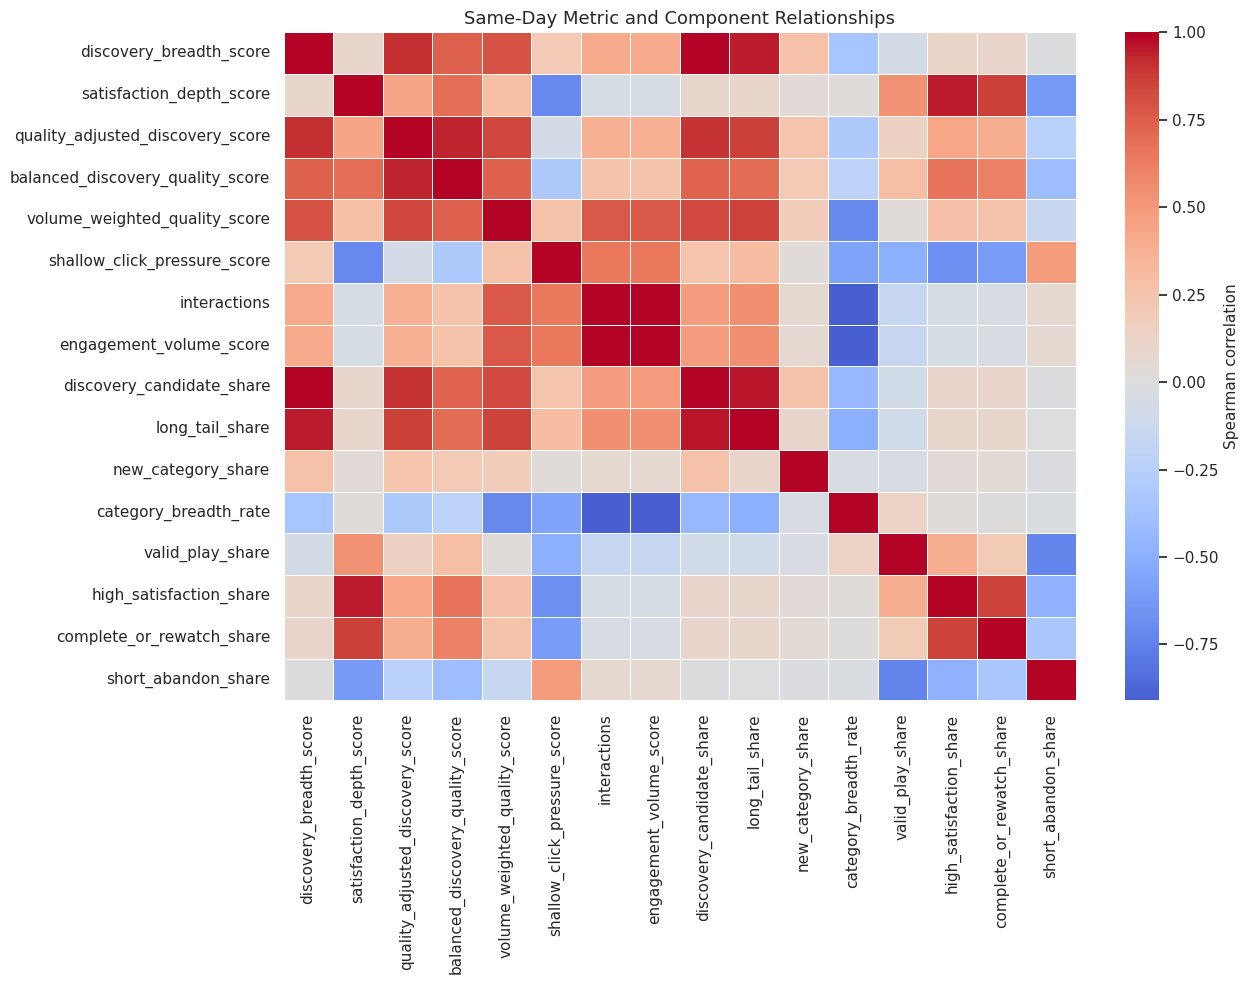

,discovery_breadth_score,satisfaction_depth_score,quality_adjusted_discovery_score,balanced_discovery_quality_score,volume_weighted_quality_score,shallow_click_pressure_score,interactions,engagement_volume_score,discovery_candidate_share,long_tail_share,new_category_share,category_breadth_rate,valid_play_share,high_satisfaction_share,complete_or_rewatch_share,short_abandon_share
discovery_breadth_score,1.000,0.093,0.904,0.745,0.792,0.208,0.410,0.410,0.993,0.949,0.263,-0.344,-0.069,0.108,0.101,-0.013
satisfaction_depth_score,0.093,1.000,0.439,0.688,0.289,-0.713,-0.052,-0.052,0.090,0.083,0.033,0.019,0.535,0.955,0.864,-0.617
quality_adjusted_discovery_score,0.904,0.439,1.000,0.934,0.838,-0.073,0.373,0.373,0.898,0.859,0.251,-0.313,0.142,0.431,0.392,-0.241
balanced_discovery_quality_score,0.745,0.688,0.934,1.000,0.742,-0.310,0.255,0.255,0.737,0.700,0.208,-0.220,0.292,0.669,0.611,-0.405
volume_weighted_quality_score,0.792,0.289,0.838,0.742,1.000,0.268,0.774,0.774,0.833,0.852,0.183,-0.702,0.028,0.282,0.258,-0.152
shallow_click_pressure_score,0.208,-0.713,-0.073,-0.310,0.268,1.000,0.655,0.655,0.254,0.300,0.027,-0.569,-0.498,-0.682,-0.611,0.488
interactions,0.410,-0.052,0.373,0.255,0.774,0.655,1.000,1.000,0.482,0.550,0.063,-0.910,-0.160,-0.049,-0.041,0.060
engagement_volume_score,0.410,-0.052,0.373,0.255,0.774,0.655,1.000,1.000,0.482,0.550,0.063,-0.910,-0.160,-0.049,-0.041,0.060
discovery_candidate_share,0.993,0.090,0.898,0.737,0.833,0.254,0.482,0.482,1.000,0.956,0.269,-0.430,-0.079,0.104,0.098,-0.012
long_tail_share,0.949,0.083,0.859,0.700,0.852,0.300,0.550,0.550,0.956,1.000,0.105,-0.497,-0.085,0.097,0.090,-0.006


In [8]:
# Check same-day metric relationships.
same_day_columns = candidate_metrics + [
    "interactions",
    "engagement_volume_score",
    "discovery_candidate_share",
    "long_tail_share",
    "new_category_share",
    "category_breadth_rate",
    "valid_play_share",
    "high_satisfaction_share",
    "complete_or_rewatch_share",
    "short_abandon_share",
]

same_day_correlation = metric_panel[same_day_columns].corr(method="spearman")

fig, ax = plt.subplots(figsize=(13, 10))
sns.heatmap(
    same_day_correlation,
    cmap="coolwarm",
    center=0,
    linewidths=0.4,
    cbar_kws={"label": "Spearman correlation"},
    ax=ax,
)
ax.set_title("Same-Day Metric and Component Relationships")
plt.tight_layout()
plt.show()

display(same_day_correlation.round(3))


This view is a measurement audit. If two metrics are nearly identical, one may be redundant. If the shallow-click guardrail is strongly related to volume and negatively related to satisfaction, it is behaving as intended.

### Validate Against Future Outcomes

Future outcomes are excluded from the metric formulas, so they can be used as validation targets. This cell measures how each candidate metric relates to future seven-day interactions, future active days, and future play hours using Spearman correlations.

In [9]:
future_outcomes = [
    "outcome_future_7day_interactions",
    "outcome_future_7day_active_days",
    "outcome_future_7day_play_hours",
]

future_validation_rows = []
for metric in candidate_metrics:
    for outcome in future_outcomes:
        future_validation_rows.append(
            {
                "metric": metric,
                "validation_target": outcome,
                "spearman_corr": safe_spearman(metric_panel, metric, outcome),
            }
        )

future_validation = pd.DataFrame(future_validation_rows)
future_validation_wide = future_validation.pivot(
    index="metric", columns="validation_target", values="spearman_corr"
).reset_index()

display(future_validation_wide.round(3))


validation_target,metric,outcome_future_7day_active_days,outcome_future_7day_interactions,outcome_future_7day_play_hours
0,balanced_discovery_quality_score,0.282,0.403,0.479
1,discovery_breadth_score,0.398,0.567,0.539
2,quality_adjusted_discovery_score,0.386,0.527,0.564
3,satisfaction_depth_score,-0.009,0.009,0.152
4,shallow_click_pressure_score,0.341,0.392,0.262
5,volume_weighted_quality_score,0.450,0.665,0.672


These correlations are descriptive screening checks. They answer a narrower question: do the candidate metrics point in the same direction as future value? A metric can pass this validation and still require causal adjustment later.

#### 10. Compare Metric Deciles to Future Behavior

Correlation is useful, but product teams often reason in ranked groups. This cell assigns each user-day to metric deciles and compares future outcomes across the ranked distribution. The top-minus-bottom contrast is an intuitive validation check: higher metric days should generally be followed by better future outcomes, except for the shallow-click guardrail where lower is preferable.

In [10]:
# Compare metric deciles to future behavior.
decile_frames = []
metric_panel_with_deciles = metric_panel.copy()

for metric in candidate_metrics:
    decile_col = f"{metric}_decile"
    metric_panel_with_deciles[decile_col] = add_decile(metric_panel_with_deciles, metric)
    decile_summary = (
        metric_panel_with_deciles.groupby(decile_col, observed=True)
        .agg(
            user_days=("user_id", "size"),
            metric_mean=(metric, "mean"),
            future_interactions_mean=("outcome_future_7day_interactions", "mean"),
            future_active_days_mean=("outcome_future_7day_active_days", "mean"),
            future_play_hours_mean=("outcome_future_7day_play_hours", "mean"),
            same_day_satisfaction_mean=("satisfaction_depth_score", "mean"),
            same_day_discovery_mean=("discovery_breadth_score", "mean"),
        )
        .reset_index()
        .rename(columns={decile_col: "decile"})
    )
    decile_summary["metric"] = metric
    decile_frames.append(decile_summary)

metric_deciles = pd.concat(decile_frames, ignore_index=True)

decile_lift_rows = []
for metric in candidate_metrics:
    current = metric_deciles.query("metric == @metric").sort_values("decile")
    bottom = current.iloc[0]
    top = current.iloc[-1]
    decile_lift_rows.append(
        {
            "metric": metric,
            "bottom_decile_future_interactions": bottom["future_interactions_mean"],
            "top_decile_future_interactions": top["future_interactions_mean"],
            "top_minus_bottom_future_interactions": top["future_interactions_mean"] - bottom["future_interactions_mean"],
            "top_minus_bottom_future_active_days": top["future_active_days_mean"] - bottom["future_active_days_mean"],
            "top_minus_bottom_future_play_hours": top["future_play_hours_mean"] - bottom["future_play_hours_mean"],
            "top_minus_bottom_same_day_satisfaction": top["same_day_satisfaction_mean"] - bottom["same_day_satisfaction_mean"],
        }
    )

decile_lift = pd.DataFrame(decile_lift_rows).sort_values(
    "top_minus_bottom_future_interactions", ascending=False
)

display(decile_lift.round(3))
display(metric_deciles.head(12).round(3))


,metric,bottom_decile_future_interactions,top_decile_future_interactions,top_minus_bottom_future_interactions,top_minus_bottom_future_active_days,top_minus_bottom_future_play_hours,top_minus_bottom_same_day_satisfaction
4,volume_weighted_quality_score,52.346,484.152,431.806,3.621,1.082,0.082
0,discovery_breadth_score,58.174,426.412,368.238,2.918,0.860,0.022
2,quality_adjusted_discovery_score,66.829,416.454,349.624,2.648,0.902,0.150
5,shallow_click_pressure_score,137.513,421.743,284.229,2.672,0.504,-0.278
3,balanced_discovery_quality_score,137.749,402.717,264.968,1.763,0.749,0.270
1,satisfaction_depth_score,290.466,267.062,-23.404,-0.051,0.148,0.403


,decile,user_days,metric_mean,future_interactions_mean,future_active_days_mean,future_play_hours_mean,same_day_satisfaction_mean,same_day_discovery_mean,metric
0,1,820,0.080,58.174,3.830,0.146,0.628,0.080,discovery_breadth_score
1,2,820,0.175,175.549,6.187,0.437,0.614,0.175,discovery_breadth_score
2,3,820,0.246,294.405,6.705,0.715,0.599,0.246,discovery_breadth_score
3,4,820,0.286,354.070,6.788,0.852,0.601,0.286,discovery_breadth_score
4,5,820,0.317,380.283,6.870,0.924,0.610,0.317,discovery_breadth_score
5,6,819,0.343,403.112,6.829,0.973,0.614,0.343,discovery_breadth_score
6,7,820,0.368,427.234,6.901,1.028,0.624,0.368,discovery_breadth_score
7,8,820,0.396,442.509,6.904,1.051,0.620,0.396,discovery_breadth_score
8,9,820,0.429,445.273,6.902,1.057,0.627,0.429,discovery_breadth_score
9,10,820,0.514,426.412,6.749,1.006,0.650,0.514,discovery_breadth_score


The decile table translates metrics into rank-order behavior. This is especially useful for storytelling: it shows what happens when we move from low-score user-days to high-score user-days without requiring the reader to parse model coefficients yet.

#### 11. Plot Future Outcomes by Metric Decile

This cell turns the decile table into a compact visual comparison. A clean upward pattern suggests that the metric ranks user-days in a way that is aligned with future engagement. A flat or reversed pattern suggests the metric may be noisy, redundant, or potentially harmful as an optimization target.

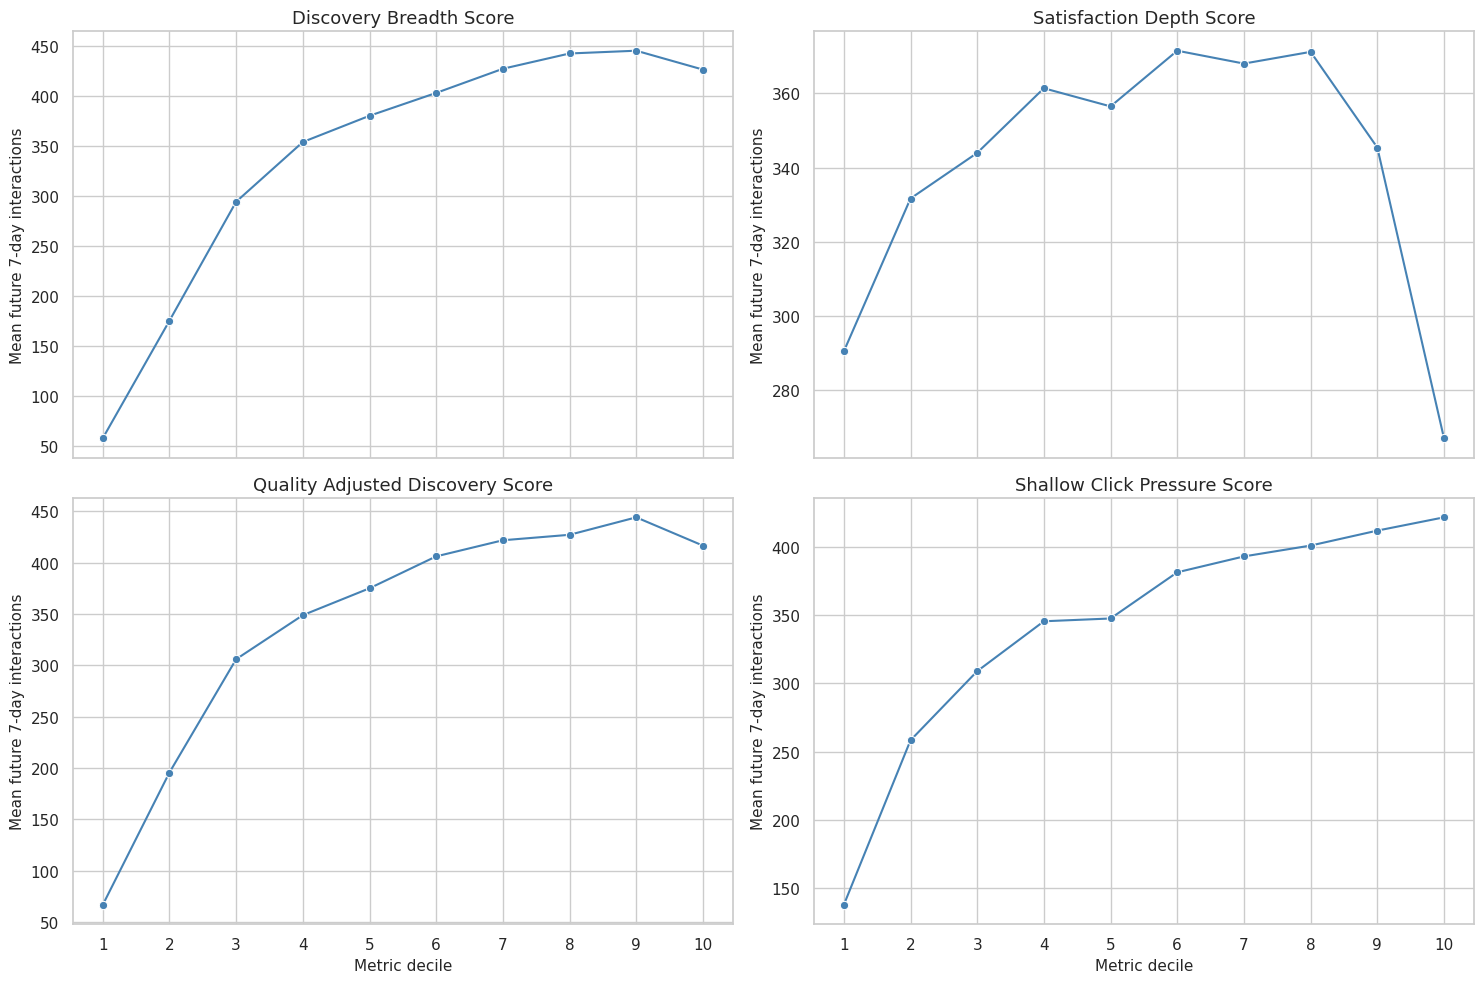

In [11]:
# Plot future outcomes by metric decile.
plot_metrics = [
    "discovery_breadth_score",
    "satisfaction_depth_score",
    "quality_adjusted_discovery_score",
    "shallow_click_pressure_score",
]
plot_deciles = metric_deciles.query("metric in @plot_metrics").copy()
plot_deciles["metric_label"] = plot_deciles["metric"].str.replace("_", " ").str.title()

fig, axes = plt.subplots(2, 2, figsize=(15, 10), sharex=True)
axes = axes.flatten()
for ax, metric in zip(axes, plot_metrics):
    current = plot_deciles.query("metric == @metric")
    sns.lineplot(
        data=current,
        x="decile",
        y="future_interactions_mean",
        marker="o",
        color="steelblue",
        ax=ax,
    )
    ax.set_title(metric.replace("_", " ").title())
    ax.set_xlabel("Metric decile")
    ax.set_ylabel("Mean future 7-day interactions")
    ax.set_xticks(range(1, 11))

plt.tight_layout()
plt.show()


The decile curves make the validation question visible. For the guardrail metric, a high score means shallow click pressure, so a weaker or negative relationship with future outcomes can be a good sign.

### Measure Stability Across Adjacent User Days

A useful product metric should contain signal. This cell computes lag-one stability within each user, meaning how much today's metric resembles yesterday's metric. High stability can indicate that a metric repeats history more than it measures new quality. A completely unstable metric may be hard to interpret or optimize.

In [12]:
stability_panel = metric_panel.sort_values(["user_id", "event_date"]).copy()
stability_rows = []

for metric in candidate_metrics:
    lag_col = f"lag_1_{metric}"
    stability_panel[lag_col] = stability_panel.groupby("user_id")[metric].shift(1)
    pair = stability_panel[["user_id", metric, lag_col]].dropna()
    lag_corr = np.nan
    if len(pair) >= 3 and pair[metric].nunique() > 1 and pair[lag_col].nunique() > 1:
        lag_corr = pair[metric].corr(pair[lag_col], method="spearman")

    user_means = stability_panel.groupby("user_id")[metric].mean()
    user_stds = stability_panel.groupby("user_id")[metric].std()
    stability_rows.append(
        {
            "metric": metric,
            "lag_1_spearman": lag_corr,
            "mean_within_user_std": user_stds.mean(),
            "between_user_std_of_means": user_means.std(),
            "overall_std": stability_panel[metric].std(),
        }
    )

metric_stability = pd.DataFrame(stability_rows).sort_values("lag_1_spearman", ascending=False)

display(metric_stability.round(3))


,metric,lag_1_spearman,mean_within_user_std,between_user_std_of_means,overall_std
4,volume_weighted_quality_score,0.683,0.165,0.029,0.167
5,shallow_click_pressure_score,0.645,0.078,0.041,0.090
1,satisfaction_depth_score,0.618,0.086,0.068,0.113
2,quality_adjusted_discovery_score,0.589,0.103,0.025,0.106
3,balanced_discovery_quality_score,0.573,0.078,0.035,0.086
0,discovery_breadth_score,0.551,0.123,0.010,0.123


Stability helps separate durable user preference signals from one-off daily noise. In later modeling, highly stable metrics may need stronger user-history adjustment, while very unstable metrics may need smoothing or larger samples.

### Check Dependence on Past Activity

A metric can look predictive simply because active users stay active. This cell checks how strongly each metric correlates with recent user history. A metric that predicts future outcomes while only moderately tracking past activity is more interesting than one that is just a disguised activity count.

In [13]:
history_columns = [
    "prior_3day_interactions",
    "recent_activity_score",
    "prior_3day_high_satisfaction_share",
    "prior_3day_discovery_candidate_share",
]

history_rows = []
for metric in candidate_metrics:
    for history_col in history_columns:
        history_rows.append(
            {
                "metric": metric,
                "history_variable": history_col,
                "spearman_corr": safe_spearman(metric_panel, metric, history_col),
            }
        )

history_dependence = pd.DataFrame(history_rows)
history_dependence_wide = history_dependence.pivot(
    index="metric", columns="history_variable", values="spearman_corr"
).reset_index()

display(history_dependence_wide.round(3))


history_variable,metric,prior_3day_discovery_candidate_share,prior_3day_high_satisfaction_share,prior_3day_interactions,recent_activity_score
0,balanced_discovery_quality_score,0.348,0.358,0.248,0.248
1,discovery_breadth_score,0.498,-0.027,0.401,0.401
2,quality_adjusted_discovery_score,0.463,0.203,0.357,0.357
3,satisfaction_depth_score,0.005,0.584,-0.046,-0.046
4,shallow_click_pressure_score,0.369,-0.410,0.444,0.444
5,volume_weighted_quality_score,0.598,0.177,0.565,0.565


This table summarizes metric behavior before confounding adjustment. It is a diagnostic. If a candidate metric is very close to recent activity, future causal notebooks should be especially careful with user fixed effects, lag controls, or doubly robust adjustment.

### Summarize Metric Validation Evidence

This cell combines distribution quality, future-outcome alignment, decile lift, stability, and history dependence into one validation table. The table is a diagnostic summary for deciding which variables are usable. It is a structured way to decide which metrics deserve to move forward.

In [14]:
# Summarize metric validation evidence.
distribution_checks = (
    metric_panel[candidate_metrics]
    .agg(["mean", "std", "min", "max"])
    .T.reset_index()
    .rename(columns={"index": "metric", "std": "metric_std"})
)
distribution_checks["missing_rate"] = metric_panel[candidate_metrics].isna().mean().values

future_score = future_validation_wide.rename(
    columns={
        "outcome_future_7day_interactions": "future_interactions_corr",
        "outcome_future_7day_active_days": "future_active_days_corr",
        "outcome_future_7day_play_hours": "future_play_hours_corr",
    }
)

history_score = history_dependence_wide.rename(
    columns={
        "prior_3day_interactions": "prior_interactions_corr",
        "recent_activity_score": "recent_activity_corr",
        "prior_3day_high_satisfaction_share": "prior_satisfaction_corr",
        "prior_3day_discovery_candidate_share": "prior_discovery_corr",
    }
)

validation_summary = (
    distribution_checks.merge(future_score, on="metric", how="left")
    .merge(history_score, on="metric", how="left")
    .merge(decile_lift, on="metric", how="left")
    .merge(metric_stability, on="metric", how="left")
)

validation_summary["future_alignment_score"] = validation_summary[
    ["future_interactions_corr", "future_active_days_corr", "future_play_hours_corr"]
].mean(axis=1)
validation_summary["history_dependence_score"] = validation_summary[
    ["prior_interactions_corr", "recent_activity_corr"]
].abs().mean(axis=1)
validation_summary["screening_score"] = (
    validation_summary["future_alignment_score"]
    - 0.35 * validation_summary["history_dependence_score"]
)

validation_summary = validation_summary.sort_values("screening_score", ascending=False)

display(
    validation_summary[
        [
            "metric",
            "metric_std",
            "future_alignment_score",
            "history_dependence_score",
            "screening_score",
            "top_minus_bottom_future_interactions",
            "lag_1_spearman",
            "missing_rate",
        ]
    ].round(3)
)


,metric,metric_std,future_alignment_score,history_dependence_score,screening_score,top_minus_bottom_future_interactions,lag_1_spearman,missing_rate
4,volume_weighted_quality_score,0.167,0.596,0.565,0.398,431.806,0.683,0.0
2,quality_adjusted_discovery_score,0.106,0.492,0.357,0.367,349.624,0.589,0.0
0,discovery_breadth_score,0.123,0.502,0.401,0.361,368.238,0.551,0.0
3,balanced_discovery_quality_score,0.086,0.388,0.248,0.301,264.968,0.573,0.0
5,shallow_click_pressure_score,0.090,0.332,0.444,0.176,284.229,0.645,0.0
1,satisfaction_depth_score,0.113,0.051,0.046,0.035,-23.404,0.618,0.0


The screening score is deliberately lightweight. It rewards future alignment and penalizes dependence on recent activity; causal estimation happens in later notebooks. Its job is to narrow attention to the metrics that are worth modeling next.

#### 15. Visualize the Validation Summary

This cell creates a figure that places future alignment and history dependence side by side. The best candidates are usually those with meaningful future alignment and tolerable dependence on prior activity. The guardrail metric should be read differently because high values represent worse quality pressure.

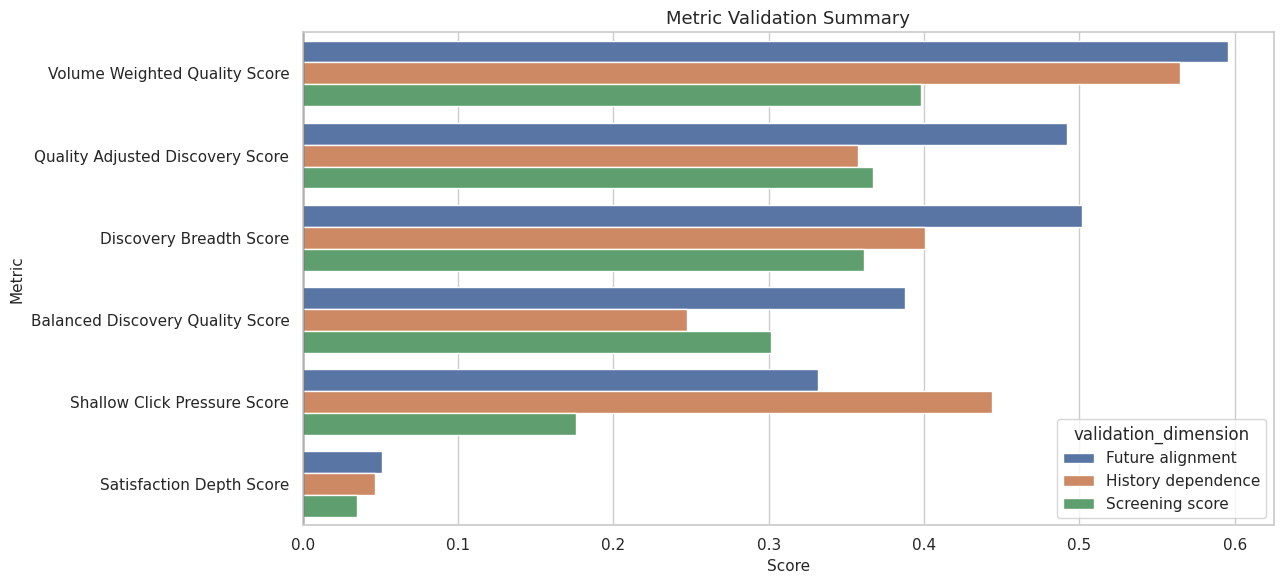

In [15]:
# Visualize the validation summary.
summary_plot = validation_summary.copy()
summary_plot["metric_label"] = summary_plot["metric"].str.replace("_", " ").str.title()
summary_long = summary_plot.melt(
    id_vars=["metric", "metric_label"],
    value_vars=["future_alignment_score", "history_dependence_score", "screening_score"],
    var_name="validation_dimension",
    value_name="score",
)
summary_long["validation_dimension"] = summary_long["validation_dimension"].map(
    {
        "future_alignment_score": "Future alignment",
        "history_dependence_score": "History dependence",
        "screening_score": "Screening score",
    }
)

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(
    data=summary_long,
    x="score",
    y="metric_label",
    hue="validation_dimension",
    ax=ax,
)
ax.axvline(0, color="black", linewidth=1)
ax.set_title("Metric Validation Summary")
ax.set_xlabel("Score")
ax.set_ylabel("Metric")
plt.tight_layout()
plt.show()


The visual summary is useful for technical communication because it shows the tradeoff in one place. A candidate metric is stronger when it has enough future signal without becoming just another activity-volume measure.

### Select Metrics for Later Causal Steps

This cell chooses the metrics that will move forward. The choices preserve causal roles: an exposure-like metric for treatment, a satisfaction metric for mediation, a composite metric for product-level monitoring, and a guardrail for shallow engagement pressure.

In [16]:
# Select metrics for later causal notebooks.
selected_metrics = pd.DataFrame(
    [
        {
            "selected_for": "exposure_analysis",
            "metric": "discovery_breadth_score",
            "reason": "Purest discovery exposure score; does not use future outcomes or satisfaction depth as a defining component.",
        },
        {
            "selected_for": "mediator_analysis",
            "metric": "satisfaction_depth_score",
            "reason": "Aggregates several same-day quality signals and is appropriate as a mediator candidate.",
        },
        {
            "selected_for": "product_metric_monitoring",
            "metric": "quality_adjusted_discovery_score",
            "reason": "Requires both discovery breadth and satisfaction depth to be high, making it a useful composite quality metric.",
        },
        {
            "selected_for": "guardrail_monitoring",
            "metric": "shallow_click_pressure_score",
            "reason": "Flags high-volume days with low satisfaction, useful as a warning against click-only optimization.",
        },
    ]
)

selected_validation = selected_metrics.merge(
    validation_summary[
        [
            "metric",
            "future_alignment_score",
            "history_dependence_score",
            "screening_score",
            "top_minus_bottom_future_interactions",
        ]
    ],
    on="metric",
    how="left",
)

display(selected_validation.round(3))


,selected_for,metric,reason,future_alignment_score,history_dependence_score,screening_score,top_minus_bottom_future_interactions
0,exposure_analysis,discovery_breadth_score,Purest discovery exposure score; does not use future outcomes or satisfaction depth as a defining component.,0.502,0.401,0.361,368.238
1,mediator_analysis,satisfaction_depth_score,Aggregates several same-day quality signals and is appropriate as a mediator candidate.,0.051,0.046,0.035,-23.404
2,product_metric_monitoring,quality_adjusted_discovery_score,"Requires both discovery breadth and satisfaction depth to be high, making it a useful composite quality metric.",0.492,0.357,0.367,349.624
3,guardrail_monitoring,shallow_click_pressure_score,"Flags high-volume days with low satisfaction, useful as a warning against click-only optimization.",0.332,0.444,0.176,284.229


The selected set gives the next notebooks a clean structure. Exposure comes first, mediator second, product composite third, with the guardrail alongside them. That keeps the causal story easy to follow.

In [ ]:
#| include: false
# Save metric artifacts.
metric_panel.to_parquet(METRIC_PANEL_OUTPUT, index=False)
metric_registry.to_csv(METRIC_REGISTRY_OUTPUT, index=False)
validation_summary.to_csv(METRIC_VALIDATION_OUTPUT, index=False)
same_day_correlation.to_csv(METRIC_CORRELATION_OUTPUT)
metric_deciles.to_csv(METRIC_DECILE_OUTPUT, index=False)
selected_validation.to_csv(METRIC_SELECTION_OUTPUT, index=False)



The saved artifacts are the handoff point. The next notebook can focus on mediation estimands and assumptions because metric construction is now explicit, validated, and reproducible. This keeps the analysis auditable: a reader can trace the final claim back to the exact table, figure, or markdown artifact that produced it.


### Takeaways and Next Step

This notebook created a measurement layer for discovery quality. The main takeaways are listed below.

- Discovery-quality measurement should separate exposure, mediator, composite, and guardrail roles.
- `discovery_breadth_score` is the cleanest exposure-like metric for later causal contrasts.
- `satisfaction_depth_score` is the main mediator candidate because it aggregates watch-quality signals without using future outcomes.
- `quality_adjusted_discovery_score` is useful as a product-facing metric, but it combines exposure and mediator information.
- Future outcomes validate the direction of the metrics, while history-dependence checks remind us why causal adjustment is still needed.

The natural next notebook is `03_mediation_estimands_and_assumptions.ipynb`, where these metrics can be mapped to direct, indirect, and total effect estimands.